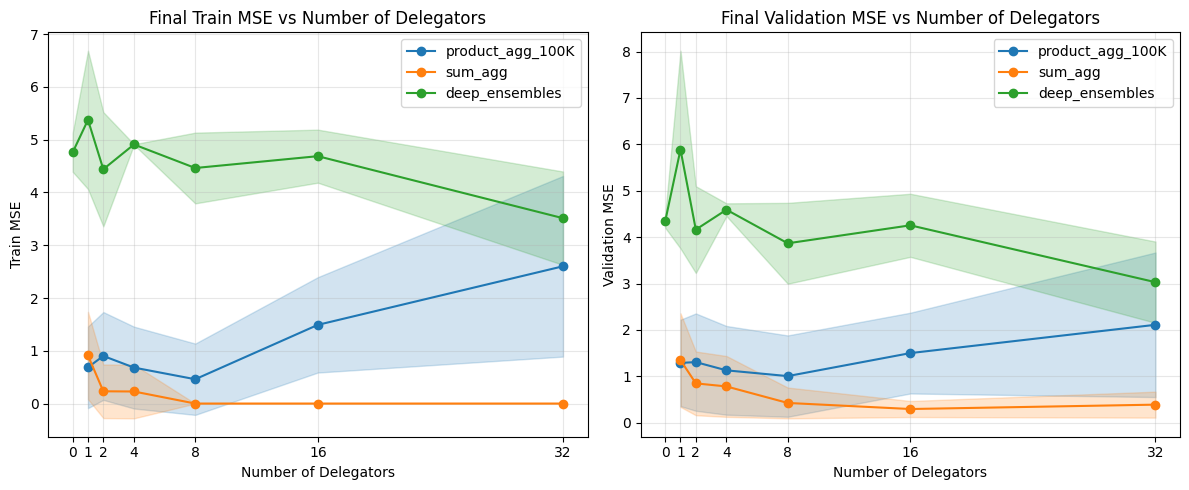

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
from pathlib import Path

BASE_DIR = Path.cwd() / "synthetic_runs"
EXPERIMENTS = ["product_agg_100K", "sum_agg", "deep_ensembles"]

def get_final_losses(exp_dir):
    train_files = list(exp_dir.glob("ndel_*_train_mse.npy"))
    
    n_dels = []
    for f in train_files:
        match = re.search(r"ndel_(\d+)_train_mse.npy", f.name)
        if match:
            n_dels.append(int(match.group(1)))
    
    n_dels.sort()
    
    train_means, train_cis = [], []
    val_means, val_cis = [], []
    
    for nd in n_dels:
        train_data = np.load(exp_dir / f"ndel_{nd}_train_mse.npy")
        val_data = np.load(exp_dir / f"ndel_{nd}_val_mse.npy")
        
        final_train = train_data[:, -1]
        final_val = val_data[:, -1]
        
        n_seeds = len(final_train)
        
        t_mean = np.mean(final_train)
        t_se = stats.sem(final_train)
        t_ci = t_se * stats.t.ppf((1 + 0.95) / 2., n_seeds - 1)
        train_means.append(t_mean)
        train_cis.append(t_ci)
        
        v_mean = np.mean(final_val)
        v_se = stats.sem(final_val)
        v_ci = v_se * stats.t.ppf((1 + 0.95) / 2., n_seeds - 1)
        val_means.append(v_mean)
        val_cis.append(v_ci)
        
    return n_dels, np.array(train_means), np.array(train_cis), np.array(val_means), np.array(val_cis)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for exp_name in EXPERIMENTS:
    exp_dir = BASE_DIR / exp_name
        
    n_dels, t_mean, t_ci, v_mean, v_ci = get_final_losses(exp_dir)


    if (len(n_dels) == 1) and (n_dels[0] == 0):
        ax1.axhline(t_mean, linestyle="dashed", color="black")
        ax2.axhline(v_mean, linestyle="dashed", color="black")
        continue

    
    line1 = ax1.plot(n_dels, t_mean, marker='o', label=exp_name)[0]
    ax1.fill_between(n_dels, t_mean - t_ci, t_mean + t_ci, alpha=0.2, color=line1.get_color())
    
    line2 = ax2.plot(n_dels, v_mean, marker='o', label=exp_name)[0]
    ax2.fill_between(n_dels, v_mean - v_ci, v_mean + v_ci, alpha=0.2, color=line2.get_color())

ax1.set_title("Final Train MSE vs Number of Delegators")
ax1.set_xlabel("Number of Delegators")
ax1.set_ylabel("Train MSE")
ax1.set_xticks(n_dels)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_title("Final Validation MSE vs Number of Delegators")
ax2.set_xlabel("Number of Delegators")
ax2.set_ylabel("Validation MSE")
ax2.set_xticks(n_dels)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from cifar10 import Cifar10
from svhn import Svhn
from energy import Energy
from bikes import Bikes

Tasks = [Cifar10, Svhn, Energy, Bik]

fro 
x, y = Cifar10.get_xy(Cifar10.load_cpu("train"))
(x.nbytes + y.nbytes) / 

In [ ]:
print((y.nbytes) / 1_000_000_000)

0.0004


: 